# Mount Google Drive/Provide image path



Mounted at /content/drive


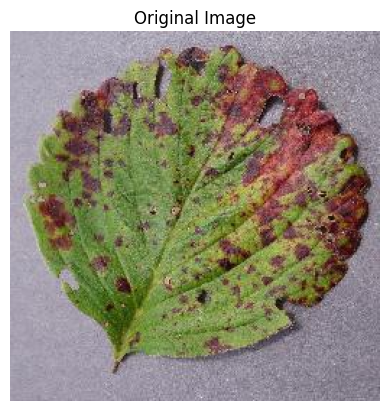

In [1]:
from google.colab import drive
import cv2
import os
import matplotlib.pyplot as plt

# Mount Google Drive
drive.mount('/content/drive')
dataset_path = '/content/drive/MyDrive/preprocessed_dataset.zip'
image_path = '/content/strawberry_scrab_leaf.JPG'

# Load the sample image
sample_image = cv2.imread(image_path)  # Load the image
sample_image = cv2.cvtColor(sample_image, cv2.COLOR_BGR2RGB)  # Convert from BGR to RGB
plt.imshow(sample_image)
plt.title("Original Image")
plt.axis("off")
plt.show()

# Applying Image segmentation Techniques

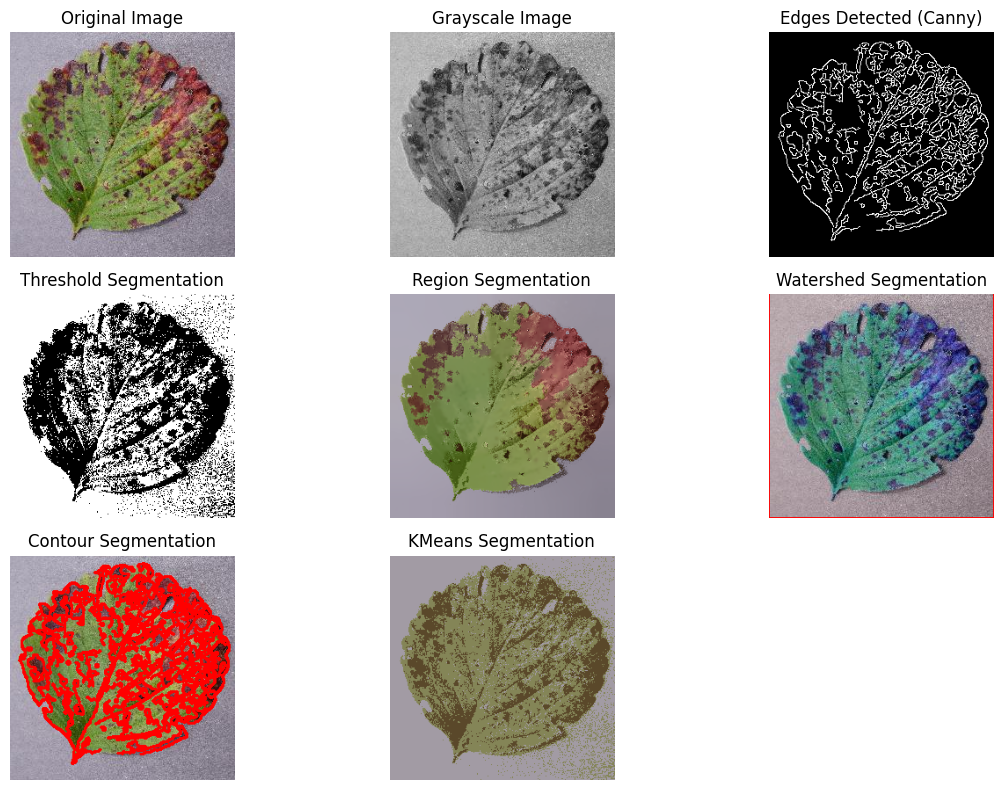

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def load_and_preprocess_image(image_path):
    sample_image = cv2.imread(image_path)
    original_image_rgb = cv2.cvtColor(sample_image, cv2.COLOR_BGR2RGB)
    gray_image = cv2.cvtColor(sample_image, cv2.COLOR_BGR2GRAY)
    return sample_image, original_image_rgb, gray_image

def threshold_segmentation(gray_image):
    _, binary_image = cv2.threshold(gray_image, 127, 255, cv2.THRESH_BINARY)
    return binary_image

def region_segmentation(original_image_rgb):
    mean_shifted = cv2.pyrMeanShiftFiltering(original_image_rgb, sp=20, sr=30)
    return mean_shifted

def watershed_segmentation(sample_image, binary_image):
    _, markers = cv2.connectedComponents(binary_image)
    markers = markers + 1
    markers = cv2.watershed(sample_image, markers)
    watershed_image = sample_image.copy()
    watershed_image[markers == -1] = [255, 0, 0]
    return watershed_image

def canny_edge_detection(gray_image):
    blurred_image = cv2.GaussianBlur(gray_image, (5, 5), 0)
    edges = cv2.Canny(blurred_image, threshold1=50, threshold2=150)
    return edges

def contour_segmentation(original_image_rgb, edges):
    contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    contour_image = original_image_rgb.copy()
    cv2.drawContours(contour_image, contours, -1, (255, 0, 0), 2)
    return contour_image

def kmeans_segmentation(original_image_rgb, k=3):
    pixel_values = original_image_rgb.reshape((-1, 3))
    pixel_values = np.float32(pixel_values)
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)
    _, labels, centers = cv2.kmeans(pixel_values, k, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)
    centers = np.uint8(centers)
    segmented_image = centers[labels.flatten()]
    segmented_image = segmented_image.reshape(original_image_rgb.shape)
    return segmented_image

def display_results(original_image_rgb, gray_image, edges, binary_image, mean_shifted, watershed_image, contour_image, segmented_image):
    plt.figure(figsize=(12, 8))

    plt.subplot(3, 3, 1)
    plt.imshow(original_image_rgb)
    plt.title("Original Image")
    plt.axis('off')

    plt.subplot(3, 3, 2)
    plt.imshow(gray_image, cmap='gray')
    plt.title("Grayscale Image")
    plt.axis('off')

    plt.subplot(3, 3, 3)
    plt.imshow(edges, cmap='gray')
    plt.title("Edges Detected (Canny)")
    plt.axis('off')

    plt.subplot(3, 3, 4)
    plt.imshow(binary_image, cmap='gray')
    plt.title("Threshold Segmentation")
    plt.axis('off')

    plt.subplot(3, 3, 5)
    plt.imshow(mean_shifted)
    plt.title("Region Segmentation")
    plt.axis('off')

    plt.subplot(3, 3, 6)
    plt.imshow(watershed_image)
    plt.title("Watershed Segmentation")
    plt.axis('off')

    plt.subplot(3, 3, 7)
    plt.imshow(contour_image)
    plt.title("Contour Segmentation")
    plt.axis('off')

    plt.subplot(3, 3, 8)
    plt.imshow(segmented_image)
    plt.title("KMeans Segmentation")
    plt.axis('off')

    plt.tight_layout()
    plt.show()

# Main code execution
image_path = '/content/strawberry_scrab_leaf.JPG'
sample_image, original_image_rgb, gray_image = load_and_preprocess_image(image_path)

binary_image = threshold_segmentation(gray_image)
mean_shifted = region_segmentation(original_image_rgb)
watershed_image = watershed_segmentation(sample_image, binary_image)
edges = canny_edge_detection(gray_image)
contour_image = contour_segmentation(original_image_rgb, edges)
segmented_image = kmeans_segmentation(original_image_rgb)

display_results(original_image_rgb, gray_image, edges, binary_image, mean_shifted, watershed_image, contour_image, segmented_image)

# Feature Extraction

GLCM Features: {'contrast': 588.5671787143203, 'dissimilarity': 17.275835450908268, 'homogeneity': 0.07884095688885714, 'ASM': 0.00016977728433761918, 'energy': 0.013023205195504286, 'correlation': 0.769718427154809}
Color Histogram Features:
Blue channel histogram values: [[0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [2.0], [0.0], [1.0], [2.0], [0.0], [0.0], [1.0], [2.0], [1.0], [0.0], [3.0], [4.0], [0.0], [4.0], [3.0], [6.0], [3.0], [5.0], [7.0], [5.0], [8.0], [13.0], [12.0], [13.0], [23.0], [23.0], [23.0], [14.0], [37.0], [25.0], [25.0], [31.0], [35.0], [29.0], [35.0], [48.0], [44.0], [33.0], [31.0], [41.0], [58.0], [59.0], [73.0], [59.0], [54.0], [53.0], [62.0], [85.0], [88.0], [81.0], [82.0], [93.0], [88.0], [102.0], [78.0], [103.0], [112.0], [111.0], [140.0], [123.0], [114.0], [141.0], [129.0], [151.0], [124.0], [121.0], [138.0], [140.0], [151.0], [162.0], [169.0], [185.0], [211.0], [232.0], [200.0], [222.0], [225.0], [242.0], [234.0], [244.0], [253.0], [232.0], [263.0], [278

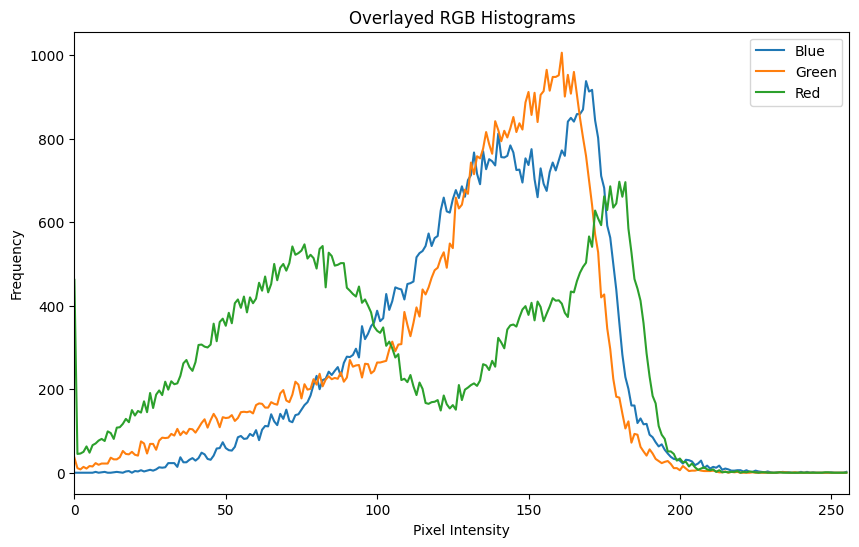

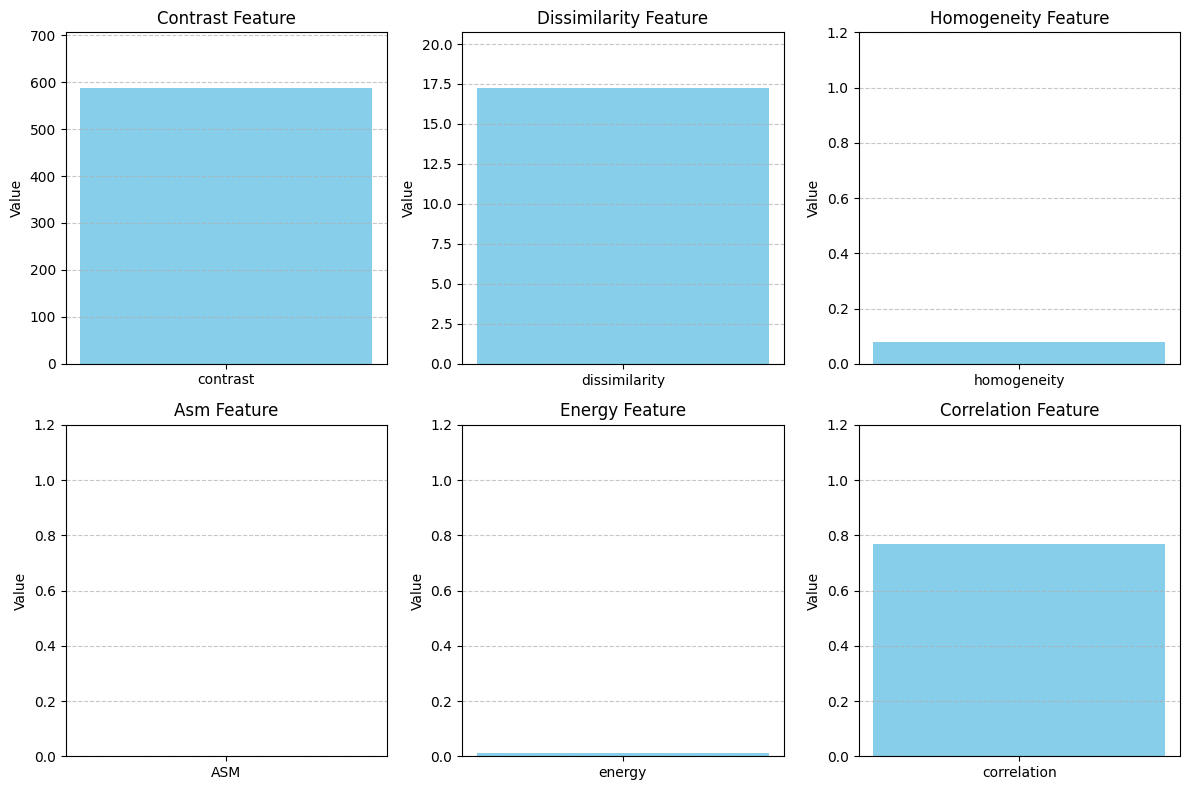

In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import graycomatrix, graycoprops

image = cv2.imread(image_path)
original_image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
_, binary_image = cv2.threshold(gray_image, 127, 255, cv2.THRESH_BINARY)
contours, _ = cv2.findContours(binary_image, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Function to extract GLCM texture features
def extract_glcm_features(gray_image):
    distances = [1]  # Pixel pair distance
    angles = [0, np.pi/4, np.pi/2, 3*np.pi/4]  # Angles for GLCM
    glcm = graycomatrix(gray_image, distances, angles, levels=256, symmetric=True, normed=True)

    features = {
        'contrast': graycoprops(glcm, 'contrast').mean(),
        'dissimilarity': graycoprops(glcm, 'dissimilarity').mean(),
        'homogeneity': graycoprops(glcm, 'homogeneity').mean(),
        'ASM': graycoprops(glcm, 'ASM').mean(),
        'energy': graycoprops(glcm, 'energy').mean(),
        'correlation': graycoprops(glcm, 'correlation').mean()
    }
    return features

# Function to compute color histograms
def compute_color_histograms(image):
    histograms = {}
    for i, color in enumerate(['blue', 'green', 'red']):
        hist = cv2.calcHist([image], [i], None, [256], [0, 256])
        histograms[color] = hist
    return histograms

# Function to calculate shape features from contours
def calculate_shape_features(contours):
    shape_features = []
    for contour in contours:
        area = cv2.contourArea(contour)
        perimeter = cv2.arcLength(contour, True)
        shape_features.append({'area': area, 'perimeter': perimeter})
    return shape_features

# Step 1: GLCM Texture Features
glcm_features = extract_glcm_features(gray_image)
print("GLCM Features:", glcm_features)

# Step 2: Color Histogram Features
color_histograms = compute_color_histograms(original_image_rgb)
print("Color Histogram Features:")
for color, hist_values in color_histograms.items():
    print(f"{color.capitalize()} channel histogram values: {hist_values.tolist()}")

# Step 3: Shape Features from Contours
shape_features = calculate_shape_features(contours)
print("Shape Features:", shape_features)

# Overlay Histograms for RGB Channels
plt.figure(figsize=(10, 6))
for color, hist in color_histograms.items():
    plt.plot(hist, label=color.capitalize())
plt.title("Overlayed RGB Histograms")
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')
plt.legend()
plt.xlim([0, 256])

# Ploting each GLCM feature individually
plt.figure(figsize=(12, 8))
for i, (feature_name, feature_value) in enumerate(glcm_features.items(), start=1):
    plt.subplot(2, 3, i)
    plt.bar([feature_name], [feature_value], color='skyblue')
    plt.title(f"{feature_name.capitalize()} Feature")
    plt.ylabel("Value")
    # Adjust y-limits dynamically for better visibility
    if feature_value > 1:
        plt.ylim(0, feature_value * 1.2)  # Scale for large values
    else:
        plt.ylim(0, 1.2)  # Scale for small values
    plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()